<a href="https://colab.research.google.com/github/Prafullh/hotel-management-ml/blob/main/hotel_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")

print(df.head())


          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [ ]:
print(df.shape)


(119390, 32)


In [ ]:
print(df.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7324 entries, 0 to 7323
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           7324 non-null   object 
 1   is_canceled                     7324 non-null   int64  
 2   lead_time                       7324 non-null   int64  
 3   arrival_date_year               7324 non-null   int64  
 4   arrival_date_month              7324 non-null   object 
 5   arrival_date_week_number        7323 non-null   float64
 6   arrival_date_day_of_month       7323 non-null   float64
 7   stays_in_weekend_nights         7323 non-null   float64
 8   stays_in_week_nights            7323 non-null   float64
 9   adults                          7323 non-null   float64
 10  children                        7323 non-null   float64
 11  babies                          7323 non-null   float64
 12  meal                            73

In [ ]:
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [ ]:
df["children"].fillna(0, inplace=True)
df["country"].fillna("Unknown", inplace=True)
df["agent"].fillna(0, inplace=True)
df["company"].fillna(0, inplace=True)

/tmp/ipykernel_683/1009897527.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["children"].fillna(0, inplace=True)
/tmp/ipykernel_683/1009897527.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.me

In [ ]:
df["children"] = df["children"].fillna(0)

df["country"] = df["country"].fillna("Unknown")

df["agent"] = df["agent"].fillna(0)

df["company"] = df["company"].fillna(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print(df["is_canceled"].value_counts())

is_canceled
0    63371
1    24025
Name: count, dtype: int64


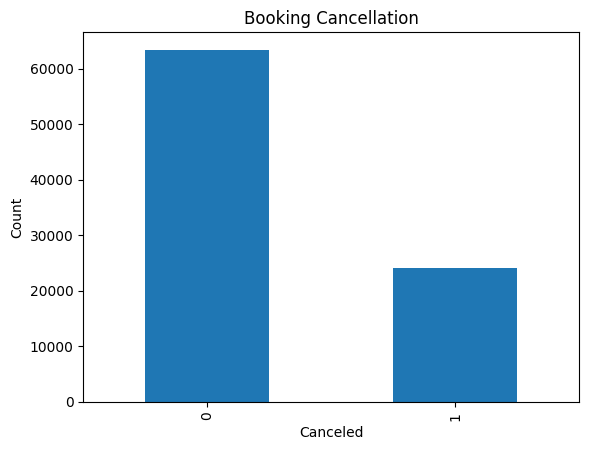

In [ ]:
import matplotlib.pyplot as plt

df["is_canceled"].value_counts().plot(kind="bar")

plt.title("Booking Cancellation")
plt.xlabel("Canceled")
plt.ylabel("Count")

plt.show()

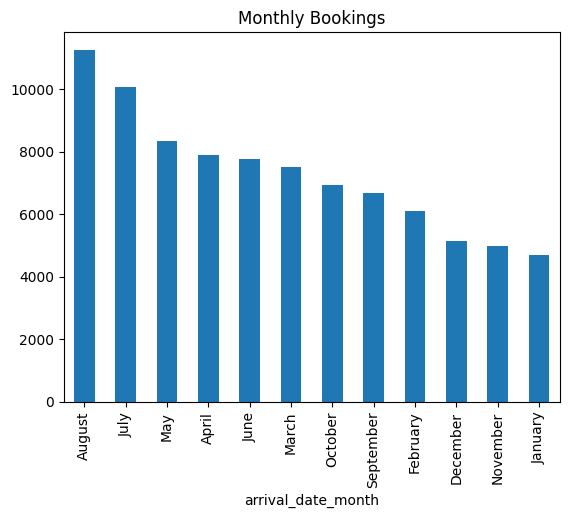

In [ ]:
monthly = df["arrival_date_month"].value_counts()

monthly.plot(kind="bar")

plt.title("Monthly Bookings")
plt.show()

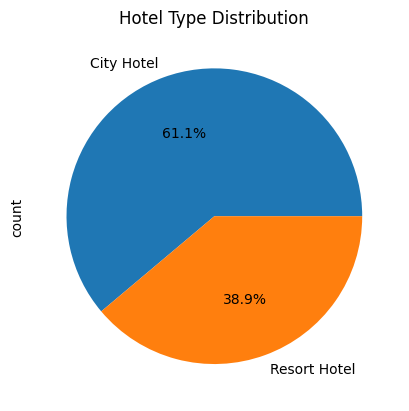

In [ ]:
df["hotel"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Hotel Type Distribution")

plt.show()

In [ ]:
features = [
    "lead_time",
    "adr",
    "adults",
    "children",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "is_repeated_guest",
    "previous_cancellations",
    "booking_changes",
    "deposit_type",
    "customer_type",
    "hotel",
    "market_segment",
    "is_canceled"
]

ml_df = df[features].copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "deposit_type",
    "customer_type",
    "hotel",
    "market_segment"
]

for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col])

In [ ]:
X = ml_df.drop("is_canceled", axis=1)

y = ml_df["is_canceled"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
print(ml_df.isnull().sum())

lead_time                  0
adr                        1
adults                     1
children                   0
stays_in_week_nights       1
stays_in_weekend_nights    1
is_repeated_guest          1
previous_cancellations     1
booking_changes            1
deposit_type               0
customer_type              0
hotel                      0
market_segment             0
is_canceled                0
dtype: int64


In [ ]:
ml_df = ml_df.fillna(0)

In [ ]:
print(ml_df.isnull().sum())

lead_time                  0
adr                        0
adults                     0
children                   0
stays_in_week_nights       0
stays_in_weekend_nights    0
is_repeated_guest          0
previous_cancellations     0
booking_changes            0
deposit_type               0
customer_type              0
hotel                      0
market_segment             0
is_canceled                0
dtype: int64


In [ ]:
X = ml_df.drop("is_canceled", axis=1)

y = ml_df["is_canceled"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7496567505720824


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7502860411899314


In [ ]:
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                    Feature  Importance
0                 lead_time    0.353347
1                       adr    0.329008
4      stays_in_week_nights    0.072617
12           market_segment    0.056711
5   stays_in_weekend_nights    0.038617
9              deposit_type    0.026673
10            customer_type    0.023850
2                    adults    0.023020
8           booking_changes    0.022511
7    previous_cancellations    0.022386
3                  children    0.013545
11                    hotel    0.013352
6         is_repeated_guest    0.004362


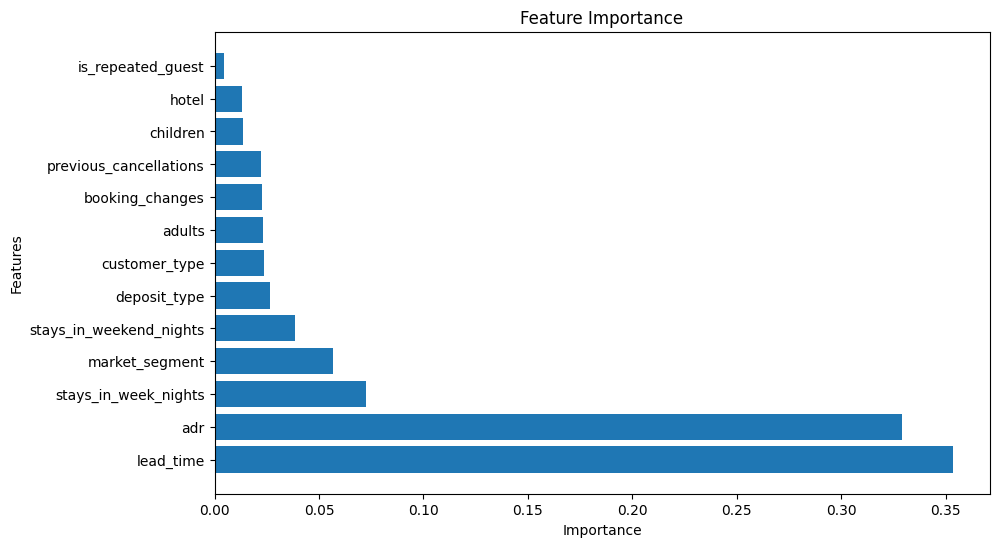

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")

plt.title("Feature Importance")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.84     12733
           1       0.55      0.43      0.48      4747

    accuracy                           0.75     17480
   macro avg       0.68      0.65      0.66     17480
weighted avg       0.74      0.75      0.74     17480



In [ ]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, rf_pred)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.6494358264953692


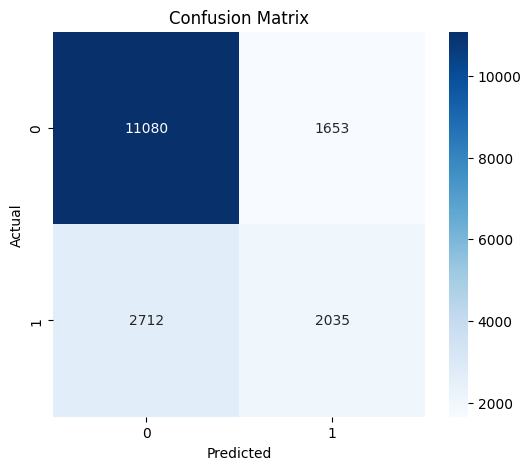

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", scores)

print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.73312357 0.67452371 0.58601751 0.61588192 0.65398478]
Average CV Score: 0.6527062975734335


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [ ]:
xgb_model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [ ]:
xgb_pred = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7652745995423341


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.78      0.94      0.85     12733
           1       0.65      0.29      0.40      4747

    accuracy                           0.77     17480
   macro avg       0.72      0.62      0.63     17480
weighted avg       0.75      0.77      0.73     17480



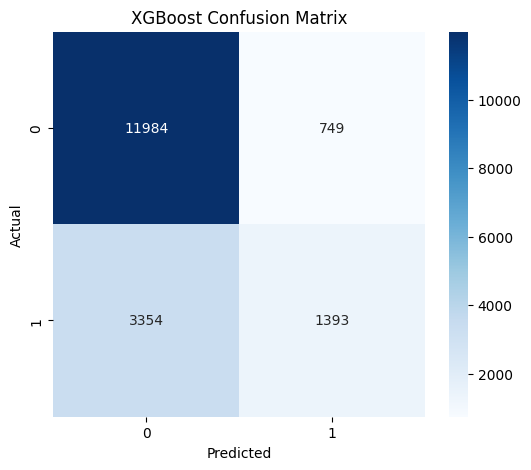

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [ ]:
import joblib

joblib.dump(xgb_model, "hotel_xgb_model.pkl")

['hotel_xgb_model.pkl']

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 41.4 MB/s eta 0:00:00
